In [1]:
import pandas as pd
from datapaths import Datapaths
import matplotlib.pyplot as plt


In [2]:
dp = Datapaths()

In [3]:
dp.print_paths()

name          | path                                                             | tags                    | type | updated at               
--------------+------------------------------------------------------------------+-------------------------+------+--------------------------
dr3_sample_v2 | /home/alex/Data/Work/Sources/gaia_vis/data/dr3_sample_v2.parquet | bailer-jones,dr3,sample | data | 2026-04-10T19:30:20+02:00
dr3_sample_v1 | /home/alex/Data/Work/Sources/gaia_vis/data/dr3_sample_v1.parquet | dr3,sample              | data | 2026-03-12T21:07:01+01:00


In [4]:
COLUMNS = [
    "source_id",
    "ra", "ra_error", "dec", "dec_error", "parallax", "parallax_error", "parallax_over_error", 
    "pm", "pmra", "pmra_error", "pmdec", "pmdec_error", "phot_g_mean_flux", "phot_g_mean_flux_error", 
    "phot_g_mean_flux_over_error", "phot_g_mean_mag", "phot_bp_mean_flux", "phot_bp_mean_flux_error", 
    "phot_bp_mean_flux_over_error", "phot_bp_mean_mag", "phot_rp_mean_flux", "phot_rp_mean_flux_error", 
    "phot_rp_mean_flux_over_error", "phot_rp_mean_mag", "bp_rp", "bp_g", "g_rp", "radial_velocity", 
    "radial_velocity_error", "phot_variable_flag", "l", "b", "ecl_lon", "ecl_lat", "in_qso_candidates", 
    "in_galaxy_candidates", "non_single_star", "teff_gspphot", "teff_gspphot_lower", "teff_gspphot_upper", 
    "logg_gspphot", "logg_gspphot_lower", "logg_gspphot_upper", "mh_gspphot", "mh_gspphot_lower", 
    "mh_gspphot_upper", "distance_gspphot", "distance_gspphot_lower", "distance_gspphot_upper"
]

### Columns explanations
#### Gaia DR3 columns
- **"source_id"**: <br>an id that is unique within given DR. Not unique across different DRs, in fact, there is no 'common' ID for the sources between different DRs - you have to use coordinate matching.
  - *Format recommendation:* **uint64**. It's a 19-digit integer; no smaller type can hold it.

- **"ra", "ra_error", "dec", "dec_error":**<br> coordinates and errors in equatorial system
  - *Format recommendation:* **float32** for all four. For visualization purposes, float32 angular precision (~0.00004° ≈ 0.14 arcsec) is far below any visible threshold in a 3D rendering. 

- **"l", "b":** <br> coordinates in galactic coordinate system (Sun is the center, *l* measured from the direction from the Sun to the center of the galaxy, *b* measures the angle above the galactic plane)
  - *Format recommendation:* **float32**. Same reasoning as ra/dec.

- **"ecl_lon", "ecl_lat":** <br> ecliptic coordinates, if we even need them (probably not, but compatibility better be ensured for Solar System visualization at some point).
  - *Format recommendation:* **float32**. 
  
- **"parallax", "parallax_error", "parallax_over_error":** <br> kinda self-explanatory. Warning: parallaxes are _somewhat_ reliable only until 1 kpc. Beyond that it's not just 'errors', it's parallaxes getting negative values (and consequently, producing negative distances) due to high astrometric noise. MW radius is at least 40 kpc. Meaning: do not use distances obtained from parallaxes (unless you're interested only in the closest 100 stars). (Sidenote: below 1 kpc parallaxes are also not the best choice - the transformation from parallax to distance is inverse, and small random errors in parallax result in heavy-tailed asymmetric errors in distances. So, use Bayesian estimates.)
  - *Format recommendation:* **float32** for parallax and parallax_error. **float32 or float16** for parallax_over_error — it's a quality indicator, not a measurement; 3 significant digits is enough to decide "good / mediocre / garbage."

- **"pm", "pmra", "pmra_error", "pmdec", "pmdec_error":** <br> proper motions with errors and its components along the *ra* and *dec* directions.
  - *Format recommendation:* **float32** for all. Typical values 0–10,000 mas/yr; float32 gives ~0.001 mas/yr precision, well below measurement errors.

- **"phot_g_mean_flux", "phot_g_mean_flux_error", 
    "phot_g_mean_flux_over_error", "phot_g_mean_mag", "phot_bp_mean_flux", "phot_bp_mean_flux_error", 
    "phot_bp_mean_flux_over_error", "phot_bp_mean_mag", "phot_rp_mean_flux", "phot_rp_mean_flux_error", 
    "phot_rp_mean_flux_over_error", "phot_rp_mean_mag":** <br> fluxes, flux errors, flux-to-error ratios, + magnitudes (-log(fluxes)) for the three Gaia filters. In practice, we'll probably ditch fluxes and use only mags, considering that mags make much more sense from perceptual point of view. 
  - *Format recommendation:* If keeping fluxes: **float32** (they span ~5–6 orders of magnitude, need the floating-point exponent). For magnitudes: **float32**, or aggressively **int16 with scale 0.001** (millimag precision over a ±32 mag range — more than sufficient). Flux-over-error ratios: **float32 or float16**, same logic as parallax_over_error. If we plan to drop fluxes in favor of magnitudes, the practical recommendation is to store only the three magnitudes as float32 or scaled int16, and recompute fluxes on the fly if ever needed.

- **"bp_rp", "bp_g", "g_rp":** <br> colors calculated from *magnitudes*. Be careful! (See the image)
  - *Format recommendation:* **float32**, or **int16 with scale 0.001**. Range roughly -1 to 6 mag; either representation gives sub-millimag precision, far beyond Gaia's photometric accuracy.

- **"radial_velocity", "radial_velocity_error":** <br> velocity of the star along the line of sight, measured with Doppler shift with RV instrument (usually, but not always)
  - *Format recommendation:* **float32**. Range roughly ±1000 km/s; float32 gives ~0.01 m/s precision at these values, while Gaia RVS precision is ~0.1–1 km/s.

- **"phot_variable_flag", "in_qso_candidates", "in_galaxy_candidates", "non_single_star":** <br> self-explanatory flags. Do not trust them too much though.
  - *Format recommendation:* **uint8** each, or pack all four into a single **uint8 bitfield** (4 bits used, 4 spare). These are boolean/categorical.

- **"teff_gspphot", "teff_gspphot_lower", "teff_gspphot_upper", "logg_gspphot", "logg_gspphot_lower", "logg_gspphot_upper", "mh_gspphot", "mh_gspphot_lower", "mh_gspphot_upper":** <br> effective surface temperature, surface gravity and metallicity, determined from fitting low-resolution Gaia spectrum to a stellar athmosphere model spectra. Gaia spectra are present not for every source, and we don't have perfect stellar athmosphere models, and the quality of the fit depends on many parameters. So yeah, don't trust it too much too). However, these are good variables to try to visualize with different colors/sizes/whatever, and they have lower and upper boundaries, so it's a good early playground for visualizing uncertainties.
  - *Format recommendation:* Teff (all three): **float32**, or **uint16** (range 0–65535 K with 1 K resolution — comfortably covers the ~2000–50000 K range, and GSP-Phot uncertainties are typically tens to hundreds of K). Logg (all three): **float32**, or **int16 with scale 0.001** (millidex precision over ±32 dex range). [M/H] (all three): same as logg — **float32** or **int16 with scale 0.001**.

- **"distance_gspphot", "distance_gspphot_lower", "distance_gspphot_upper":** <br> distances estimated from the same model spectra fit. Somewhat better than distances from parallaxes (at least they are not negative), but still not perfect. For good ones we'll have to go to Bailer-Jones catalogue. Again, useful to try to visualize lower-upper boundaries as uncertainties.
  - *Format recommendation:* **float32**. Range 0 to ~tens of kpc; float32 gives sub-pc precision even at the far end.

<div>
<img src="../plots/gaia_bands.png" width="500"/><br>
BP is shorter wavelengths, so higher energies, so <i>bluer</i>. RP is longer wavelengths->lower energies-><i>redder</i>. If we have higher fluxes in BP than in RP, then the star is 'blue' (hotter, probably younger). If the opposite, the object is 'red' (cooler, probably older, or maybe obscured by dust). However! In astronomy, we calculate colors from magnitudes, not fluxes, all the time, and mags are <i>negative log of the flux</i>. Meaning, if we have larger <i>magnitude</i> in BP than in RP, it means it has <i>lower flux</i> in this band. For this reason positive 'BP-RP', which is calculated in magnitudes, means that BP <i>flux</i> is lower than RP flux, and so the object is red, not blue.
Yes, it's a mess. 
</div>

#### Bayler-Jones (Baysian) distance catalogue

- **"source_id":**<br>
Also "source_id2" in my crossmatched catalog. The same id as in Gaia DR 3.
  - *Format recommendation:* **uint64**. But it's not like we need to convert it.
- **"r_med_geo", "r_lo_geo", "r_hi_geo"**:<br>
The median and Q16 and Q84 of the geometric distance posterior.
  - *Format recommendation:* **float32**.Same as distances from DR3.
- **"r_med_photogeo", "r_lo_photogeo", "r_hi_photogeo"**:<br>
The median and Q16 and Q84 of the **photogeometric** distance posterior (so, photometric colors and magnitudes are taken into account as priors)
  - *Format recommendation:* **float32**.Same as distances from DR3.
- **"flag"**:<br>
A flag informing about the quality of magnitudes and whether unimodal hypothesis is ok and whether two-component Gaussian model was used. 
  - *Format recommendation:* **uint16**, it's a 5-digit int.
See Tab. 2 in Bayler-Jones paper:
<div>
<img src="../plots/flags_BJ2.png" width="500"/><br>
Flags as described in https://ui.adsabs.harvard.edu/abs/2021AJ....161..147B/abstract 
</div>


In [5]:

df = pd.read_parquet(dp['dr3_sample_v2'])

In [6]:
df.describe()

,source_id,ra,ra_error,dec,dec_error,parallax,parallax_error,parallax_over_error,pm,pmra,...,distance_gspphot_lower,distance_gspphot_upper,source_id2,r_med_geo,r_lo_geo,r_hi_geo,r_med_photogeo,r_lo_photogeo,r_hi_photogeo,distance_parallax
count,9.715100e+04,97151.000000,97151.000000,97151.000000,97151.000000,97151.000000,97151.000000,97151.000000,97151.000000,97151.000000,...,31426.000000,31426.000000,9.715100e+04,97151.000000,97151.000000,97151.000000,89042.000000,89042.000000,89042.000000,9.715100e+04
mean,4.331007e+18,226.338893,0.379276,-17.601449,0.346054,0.365080,0.460914,3.622581,6.507824,-2.542479,...,1353.915527,1529.222656,4.331007e+18,4065.088623,2592.715332,6113.715332,4595.932129,3657.543457,5870.927246,3.762615e+03
std,1.682304e+18,79.735964,0.356181,37.641404,0.319057,1.007518,0.419191,15.374872,5.684912,5.404935,...,1078.395508,1149.307495,1.682304e+18,2023.940674,1314.161255,3090.860840,2683.842041,2147.867432,3454.937744,4.553263e+05
min,1.223653e+15,0.002808,0.004890,-89.538737,0.006192,-21.461309,0.008646,-14.990229,0.018559,-182.164641,...,47.271301,49.409801,1.223653e+15,47.715584,44.997917,47.764862,47.709393,42.160435,47.769238,-4.341111e+07
25%,3.461866e+18,176.751423,0.119537,-48.559051,0.113746,0.011969,0.153577,0.030485,3.576204,-4.783912,...,774.972900,919.537354,3.461866e+18,2476.165283,1621.745850,3696.650391,2579.803955,2117.796143,3130.295410,2.515963e+02
50%,4.304281e+18,257.950862,0.268595,-25.105608,0.250434,0.306598,0.340210,1.100362,5.691117,-2.509813,...,1116.730469,1296.779663,4.304281e+18,4100.933105,2485.360107,6397.047852,4312.556641,3336.969971,5677.420410,1.517897e+03
75%,5.860556e+18,281.381395,0.521640,9.883889,0.476298,0.674752,0.637935,2.647632,7.886251,-0.353593,...,1636.450684,1826.240723,5.860556e+18,5550.320068,3425.636475,8338.293945,6146.879883,4792.390625,8058.951172,3.341217e+03
max,6.917166e+18,359.988921,3.516955,89.690171,3.544657,20.938553,4.355501,879.534546,256.443420,221.514771,...,25547.148438,25910.966797,6.917166e+18,33139.148438,25476.923828,39994.464844,35854.082031,24568.414062,44245.644531,9.936256e+07


<Axes: >

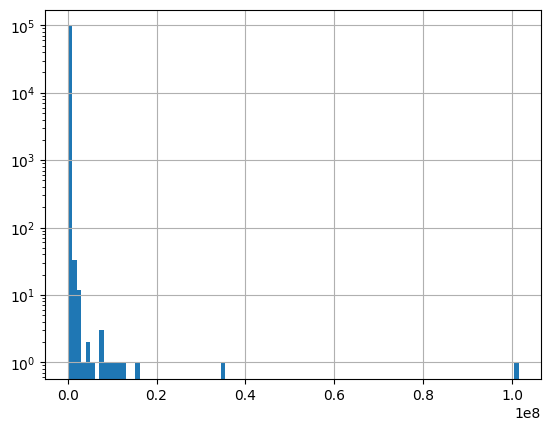

In [7]:
df['phot_g_mean_flux'].hist(log=True, bins=100)

### NaN inspection
Pay attention: we rarely have any radial velocities; we miss gspphot more often than not (because for that we need spectra, and spectra are present only for a fraction of objects, usually the brightest ones); and then we miss parallaxes for about 1/5 of the sample (although it's not like they are very useful in general...)

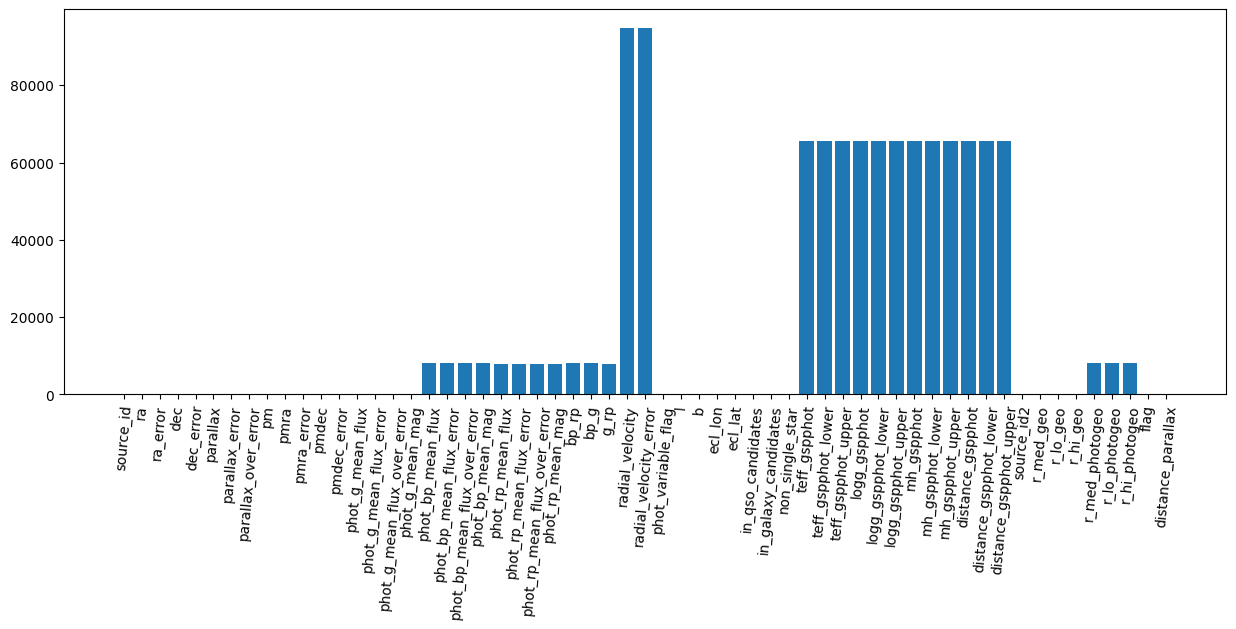

In [8]:
fig,ax = plt.subplots(nrows=1,ncols=1, figsize=(15,5))
ax.bar(range(len(df.columns)),height=df.isna().sum())
ax.set_xticks(range(len(df.columns)))
ax.set_xticklabels(list(df.columns));
ax.tick_params(axis='x', rotation=85)

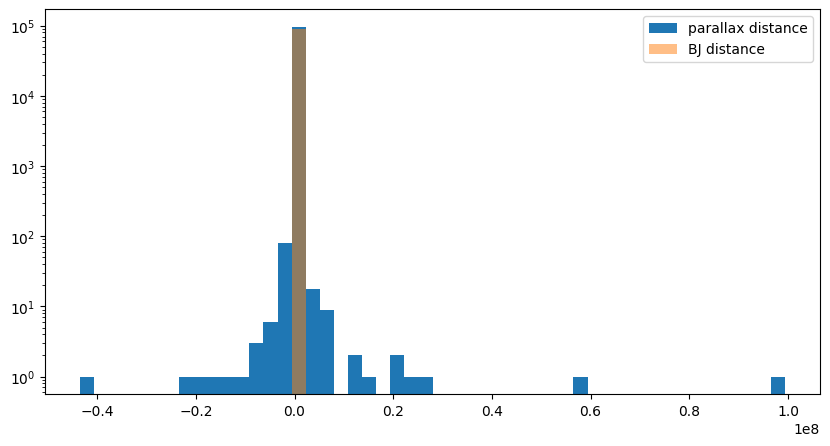

In [14]:
# Just to illustrate negative parallaxes. 
fig, ax = plt.subplots(figsize=(10,5),nrows=1,ncols=1)
bins = ax.hist(df['distance_parallax'],log=True,bins=50,label='parallax distance');
#ax.hist(df['distance_gspphot'],log=True,bins=bins[1],alpha=0.5,label='gspphot distance');
ax.hist(df['r_med_photogeo'],log=True,bins=bins[1],alpha=0.5,label='BJ distance');
ax.legend()

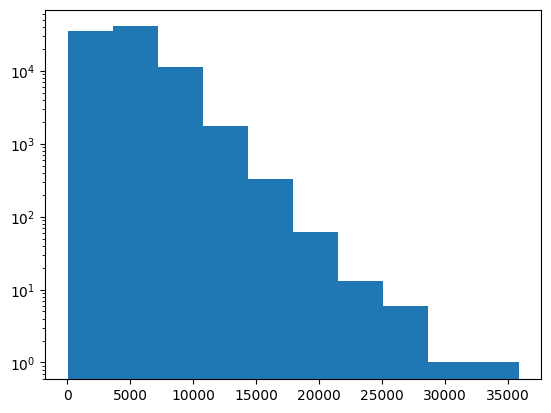

In [17]:
plt.hist(df['r_med_photogeo'],log=True,label='BJ distance');

Let's see the ratio of the width of the distributions of the distances to distances themselve.

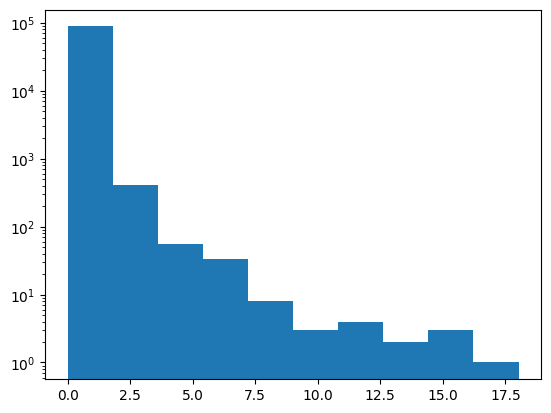

In [ ]:
mask = ~(df['r_med_photogeo'].isna()) & (df['r_hi_photogeo'] - df['r_lo_photogeo'] != 0)
plt.hist((df[mask]['r_hi_photogeo'] - df[mask]['r_lo_photogeo'])/df[mask]['r_med_photogeo'],label='BJ distance',log=True);

The Gaia visualization looks like a hedgehog, but I think my conversion to .splat really elongates the Gaussians? I leave it for you to figure out.
However, for the reference, the visualizations in the original paper (https://ui.adsabs.harvard.edu/abs/2021AJ....161..147B/abstract) also look like hedgehogs).